# Objective: 
To take the current HBCD BIBSNet volumetric data, from the tabular release, and ask the question if my locally acquired typical 6 month old subjects are consistent with the HBCD results.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
#import seaborn as 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from numpy.polynomial.polynomial import Polynomial

## Load the HBCD BIBSNet file
/shared/hbcd-1-0-release-tabulated-prod/img_bibsnet_space-T1w_desc-aseg_volumes.tsv

In [2]:
df = pd.read_csv('/shared/hbcd-1-0-release-tabulated-prod/img_bibsnet_space-T1w_desc-aseg_volumes.tsv', sep='\t')

# IF you want to see this in order to confirm, uncomment out the next line
#df.head

## Let's start with a simple plot of a sructural volume as a function of age
* Structure = img_bibsnet_space-T1w_desc-aseg_volumes_**Left-Cerebral-Cortex**
* Age = img_bibsnet_space-T1w_desc-aseg_volumes_**candidate_age**

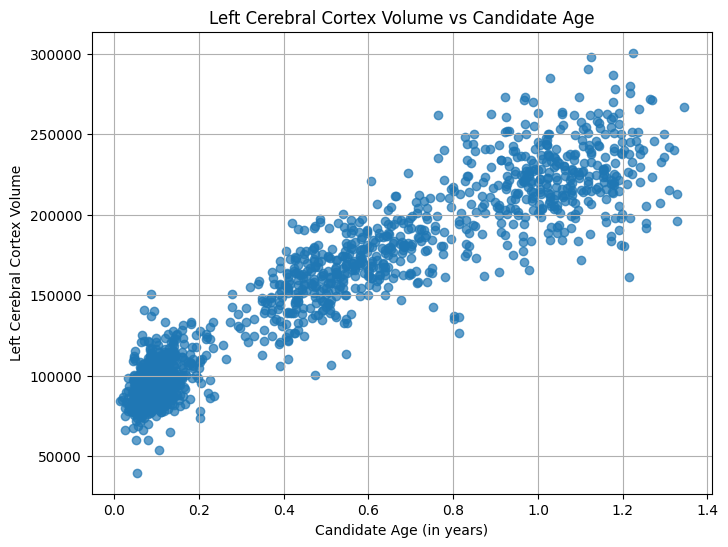

In [3]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(
    df['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
    df['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
    alpha=0.7
)
plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume')
plt.title('Left Cerebral Cortex Volume vs Candidate Age')
plt.grid(True)
plt.show()

## Digging deeper into this plot
We know that there are multiple sessions, and that subjects were potentially scanned on multiple sessions. Let's look at that content, and update the plot to reflect his.

In [4]:
# Count unique participants by session
df.groupby('session_id')['participant_id'].nunique()

session_id
ses-V02    792
ses-V03    410
ses-V04    375
Name: participant_id, dtype: int64

In [5]:
# Count the number of unique sessions per participant
session_counts = df.groupby('participant_id')['session_id'].nunique().reset_index()
session_counts = session_counts.rename(columns={'session_id': 'n_sessions'})

# Count how many subjects have N sessions
distribution = session_counts['n_sessions'].value_counts().sort_index()
print(distribution)

n_sessions
1    826
2    281
3     63
Name: count, dtype: int64


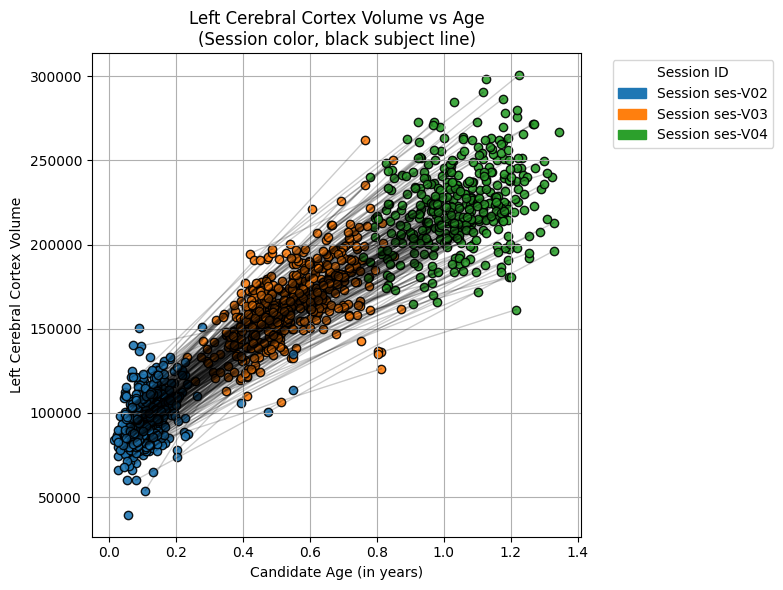

In [6]:
# Redo the above plot, but color code sesion, and connect same subject through time

# Choose a qualitative color map (extend if you have >10 sessions)
color_palette = plt.cm.tab10.colors
session_ids = sorted(df['session_id'].unique())
session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

plt.figure(figsize=(8,6))

# Plot points by session color and connect sessions for each subject
for pid, group in df.groupby('participant_id'):
    group_sorted = group.sort_values('img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age')
    
    # Plot colored points for each session
    for sid in session_ids:
        session_group = group_sorted[group_sorted['session_id'] == sid]
        if not session_group.empty:
            plt.scatter(session_group['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                        session_group['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                        color=session_colors[sid], alpha=0.9, edgecolor='black', label=None)
    # Add black connecting line for subjects with multiple sessions
    if len(group_sorted) > 1:
        plt.plot(group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                 group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                 color='black', alpha=0.2, linewidth=1)

# Custom legend for session colors
handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
plt.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume')
plt.title('Left Cerebral Cortex Volume vs Age\n(Session color, black subject line)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Fitting for age...
In this example, will fit a polynomial function with CI 

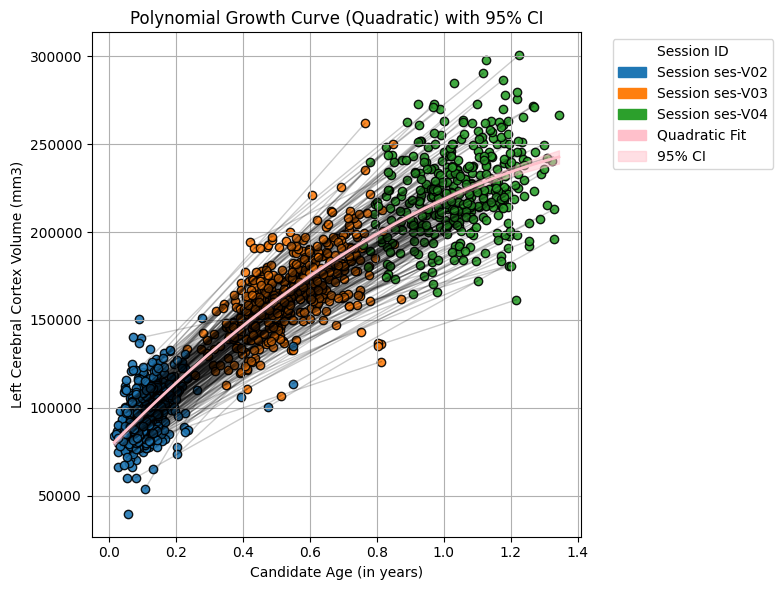

In [7]:
# Prepare data
x = df['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'].values
y = df['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'].values

# Fit a degree-2 polynomial
coefs = np.polyfit(x, y, 2)  # coefs[0]*x^2 + coefs[1]*x + coefs[2]

# Fit predictions on a smooth grid
x_curve = np.linspace(x.min(), x.max(), 200)
y_poly = np.polyval(coefs, x_curve)

# Design matrix for original data (X) and curve points (X_pred)
X = np.vstack([x**2, x, np.ones_like(x)]).T
X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T

# Estimate residual variance
y_fit = np.polyval(coefs, x)
residuals = y - y_fit
dof = len(x) - 3  # Three parameters for quadratic
residual_var = (residuals**2).sum() / dof

# Covariance matrix of coefficients
XtX_inv = np.linalg.inv(X.T @ X)
# Standard errors prediction intervals at each point
y_var_pred = np.array([residual_var * (np.dot(X_pred[i], XtX_inv @ X_pred[i])) for i in range(len(x_curve))])
y_std_pred = np.sqrt(y_var_pred)

# 95% CI
ci_upper = y_poly + 1.96 * y_std_pred
ci_lower = y_poly - 1.96 * y_std_pred
# Color mapping for sessions
color_palette = plt.cm.tab10.colors
session_ids = sorted(df['session_id'].unique())
session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

plt.figure(figsize=(8,6))

# Plot points by session color and connect lines by subject
for pid, group in df.groupby('participant_id'):
    group_sorted = group.sort_values('img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age')
    for sid in session_ids:
        session_group = group_sorted[group_sorted['session_id'] == sid]
        if not session_group.empty:
            plt.scatter(session_group['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                        session_group['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                        color=session_colors[sid], alpha=0.9, edgecolor='black', label=None)
    if len(group_sorted) > 1:
        plt.plot(group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                 group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                 color='black', alpha=0.2, linewidth=1)

# Plot polynomial fit with CI
plt.plot(x_curve, y_poly, color='pink', linewidth=2, label='Quadratic Fit')
plt.fill_between(x_curve, ci_lower, ci_upper, color='pink', alpha=0.5, label='95% CI')

# Custom legend
handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
handles += [
    mpatches.Patch(color='pink', label='Quadratic Fit'),
    mpatches.Patch(color='pink', alpha=0.5, label='95% CI')
]
plt.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume (mm3)')
plt.title('Polynomial Growth Curve (Quadratic) with 95% CI')
plt.grid(True)
plt.tight_layout()
plt.show()

# IF you wanted to...
You could plot all the structures, putting the lateralized structures side by side...

But, that takes some time, so we wont execute this in the live demo...

In [ ]:
# Plot all paired structures, left and right
def plot_left_right_pairs(
    df,
    age_col,
    participant_col,
    session_col,
    prefix="img_bibsnet_space-T1w_desc-aseg_volumes_"
):
    # Step 1: Find unique structure names for pairing
    region_cols = [col for col in df.columns if col.startswith(prefix)]
    structure_names = [col.replace(prefix, '') for col in region_cols]

    # Build dictionary of pairs: {'Cerebral-Cortex': {'Left': col, 'Right': col}}
    pairs = {}
    for name, col in zip(structure_names, region_cols):
        if name.startswith('Left-'):
            base_name = name.replace('Left-', '')
            pairs.setdefault(base_name, {})['Left'] = col
        elif name.startswith('Right-'):
            base_name = name.replace('Right-', '')
            pairs.setdefault(base_name, {})['Right'] = col

    # Get session colors
    color_palette = plt.cm.tab20.colors  # Up to 20, use tab20 for more sessions
    session_ids = sorted(df[session_col].unique())
    session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

    # Step 2: Plot for each pair
    for base_name, pair in pairs.items():
        fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
        sides = ['Left', 'Right']

        for i, side in enumerate(sides):
            if side in pair:
                region_col = pair[side]
                region_name = f"{side}-{base_name}"

                x = df[age_col].values
                y = df[region_col].values

                # Polynomial fit and CI
                coefs = np.polyfit(x, y, 2)
                x_curve = np.linspace(x.min(), x.max(), 200)
                y_poly = np.polyval(coefs, x_curve)
                X = np.vstack([x**2, x, np.ones_like(x)]).T
                X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T
                y_fit = np.polyval(coefs, x)
                residuals = y - y_fit
                dof = len(x) - 3
                residual_var = (residuals**2).sum() / dof
                XtX_inv = np.linalg.inv(X.T @ X)
                y_var_pred = np.array([residual_var * (np.dot(X_pred[j], XtX_inv @ X_pred[j])) for j in range(len(x_curve))])
                y_std_pred = np.sqrt(y_var_pred)
                ci_upper = y_poly + 1.96 * y_std_pred
                ci_lower = y_poly - 1.96 * y_std_pred

                ax = axes[i]
                # Plot session colored points and connect by subject
                for pid, group in df.groupby(participant_col):
                    group_sorted = group.sort_values(age_col)
                    for sid in session_ids:
                        session_group = group_sorted[group_sorted[session_col] == sid]
                        if not session_group.empty:
                            ax.scatter(
                                session_group[age_col], session_group[region_col],
                                color=session_colors[sid], alpha=0.9, edgecolor='black', label=None
                            )
                    if len(group_sorted) > 1:
                        ax.plot(
                            group_sorted[age_col], group_sorted[region_col],
                            color='black', alpha=0.2, linewidth=1
                        )
                # Poly fit curve and CI
                ax.plot(x_curve, y_poly, color='pink', linewidth=2, label='Quadratic Fit')
                ax.fill_between(x_curve, ci_lower, ci_upper, color='pink', alpha=0.5, label='95% CI')
                ax.set_xlabel('Candidate Age')
                ax.set_title(region_name)

        # Custom legend (put only on first subplot)
        handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
        handles += [
            mpatches.Patch(color='pink', label='Quadratic Fit'),
            mpatches.Patch(color='pink', alpha=0.5, label='95% CI')
        ]
        axes[0].legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

        axes[0].set_ylabel('Volume')
        for ax in axes:
            ax.grid(True)
        plt.suptitle(f'Polynomial Growth Curve: {base_name} (Left/Right)', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        # Optionally:
        # plt.savefig(f'growth_curve_{base_name}_left_right.png')
        plt.show()

# Usage
plot_left_right_pairs(
    df,
    age_col='img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age',
    participant_col='participant_id',
    session_col='session_id',
    prefix='img_bibsnet_space-T1w_desc-aseg_volumes_'
)

# Add UMass Data
In the file called df_merged.csv

In [8]:
# Load UMA data
df_uma = pd.read_csv('/shared/hackathon/working-area/UMA/df_merged.csv')

# If you want to check the data, uncomment out the following
#df_uma.head

## Add this to the plot...

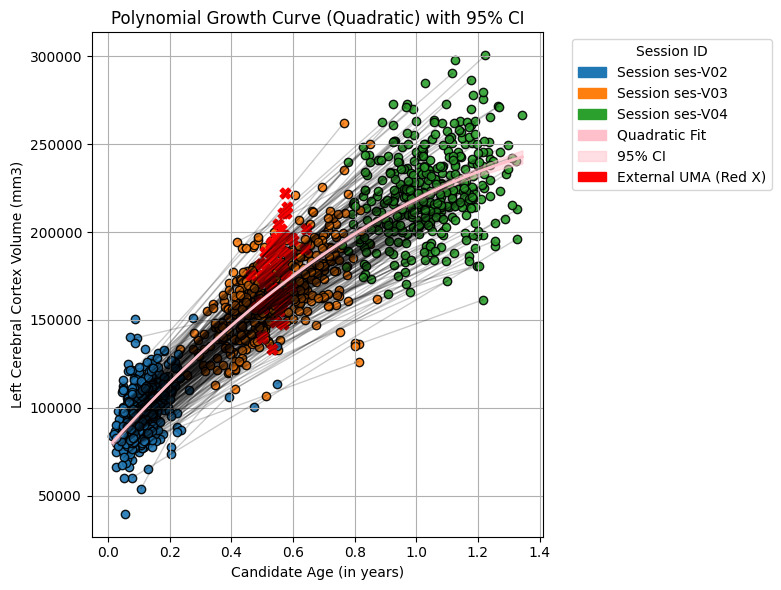

In [9]:
# ammend the plot
# Color mapping for sessions
color_palette = plt.cm.tab10.colors
session_ids = sorted(df['session_id'].unique())
session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

external_color = 'red'
external_marker = 'X'

plt.figure(figsize=(8,6))

# Plot points by session color and connect lines by subject
for pid, group in df.groupby('participant_id'):
    group_sorted = group.sort_values('img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age')
    for sid in session_ids:
        session_group = group_sorted[group_sorted['session_id'] == sid]
        if not session_group.empty:
            plt.scatter(session_group['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                        session_group['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                        color=session_colors[sid], alpha=0.9, edgecolor='black', label=None)
    if len(group_sorted) > 1:
        plt.plot(group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                 group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                 color='black', alpha=0.2, linewidth=1)

# Plot polynomial fit with CI
plt.plot(x_curve, y_poly, color='pink', linewidth=2, label='Quadratic Fit')
plt.fill_between(x_curve, ci_lower, ci_upper, color='pink', alpha=0.5, label='95% CI')

# Custom legend
handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
handles += [
    mpatches.Patch(color='pink', label='Quadratic Fit'),
    mpatches.Patch(color='pink', alpha=0.5, label='95% CI')
]
external_patch = mpatches.Patch(color=external_color, label='External UMA (Red X)')
handles += [external_patch]

plt.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume (mm3)')
plt.title('Polynomial Growth Curve (Quadratic) with 95% CI')
plt.grid(True)
plt.tight_layout()

# Plot df_uma data as red X's
plt.scatter(
    df_uma['Baby Age at Scan (Years)'],
    df_uma['Left-Cerebral-Cortex'],
    color=external_color,
    marker=external_marker,
    s=60,   # size of marker
    label='External UMA'
)
plt.show()

# As before, we COULD do this for all structures... 
Paired and unilateral, showing UMass Data relative to the HBCD data (and could rite this to a pdf for sharing...).

But, in this demo, we wont.

In [ ]:
def plot_and_export_regions(
    df,
    df_uma,
    age_col,
    participant_col,
    session_col,
    pdf_filename="all_growth_curves_plusUMA.pdf",
    prefix="img_bibsnet_space-T1w_desc-aseg_volumes_"
):
    # ---- Parameters for UMA overlay ----
    external_color = 'red'
    external_marker = 'X'
    uma_age_col = 'Baby Age at Scan (Years)'  # Age column in the UMA dataframe

    # Identify region columns and structure base names
    region_cols = [col for col in df.columns if col.startswith(prefix)]
    structure_names = [col.replace(prefix, '') for col in region_cols]
    pairs = {}
    singletons = []

    # Find pairs and unpaired
    for name, col in zip(structure_names, region_cols):
        if name.startswith('Left-'):
            base = name.replace('Left-', '')
            pairs.setdefault(base, {})['Left'] = col
        elif name.startswith('Right-'):
            base = name.replace('Right-', '')
            pairs.setdefault(base, {})['Right'] = col
        else:
            singletons.append((name, col))

    # Split pairs into true pairs and leftover singles
    paired_structures = {k: v for k, v in pairs.items() if len(v) == 2}
    leftover = [(f"Left-{k}", v['Left']) for k, v in pairs.items() if 'Left' in v and 'Right' not in v]
    leftover += [(f"Right-{k}", v['Right']) for k, v in pairs.items() if 'Right' in v and 'Left' not in v]
    all_singletons = singletons + leftover

    # Session colors
    color_palette = plt.cm.tab20.colors
    session_ids = sorted(df[session_col].unique())
    session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

    with PdfPages(pdf_filename) as pdf:
        # -- Plot left-right pairs --
        for base_name, pair in paired_structures.items():
            fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
            sides = ['Left', 'Right']
            for i, side in enumerate(sides):
                region_col = pair[side]
                region_name = f"{side}-{base_name}"
                x = df[age_col].values
                y = df[region_col].values
                # Polynomial fit and CI
                coefs = np.polyfit(x, y, 2)
                x_curve = np.linspace(x.min(), x.max(), 200)
                y_poly = np.polyval(coefs, x_curve)
                X = np.vstack([x**2, x, np.ones_like(x)]).T
                X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T
                y_fit = np.polyval(coefs, x)
                residuals = y - y_fit
                dof = len(x) - 3
                residual_var = (residuals**2).sum() / dof
                XtX_inv = np.linalg.inv(X.T @ X)
                y_var_pred = np.array([residual_var * (np.dot(X_pred[j], XtX_inv @ X_pred[j])) for j in range(len(x_curve))])
                y_std_pred = np.sqrt(y_var_pred)
                ci_upper = y_poly + 1.96 * y_std_pred
                ci_lower = y_poly - 1.96 * y_std_pred
                ax = axes[i]
                # Plot session colored points and lines
                for pid, group in df.groupby(participant_col):
                    group_sorted = group.sort_values(age_col)
                    for sid in session_ids:
                        session_group = group_sorted[group_sorted[session_col] == sid]
                        if not session_group.empty:
                            ax.scatter(
                                session_group[age_col], session_group[region_col],
                                color=session_colors[sid], alpha=0.9, edgecolor='black', label=None
                            )
                    if len(group_sorted) > 1:
                        ax.plot(
                            group_sorted[age_col], group_sorted[region_col],
                            color='black', alpha=0.2, linewidth=1
                        )
                # Poly fit curve and CI
                ax.plot(x_curve, y_poly, color='pink', linewidth=2, label='Quadratic Fit')
                ax.fill_between(x_curve, ci_lower, ci_upper, color='pink', alpha=0.5, label='95% CI')
                # --- Overlay UMA data, if available for this region ---
                uma_structure_col = region_name
                if uma_structure_col in df_uma.columns:
                    ax.scatter(
                        df_uma[uma_age_col],
                        df_uma[uma_structure_col],
                        color=external_color, marker=external_marker, s=80,
                        label='UMA Data'
                    )
                ax.set_xlabel('Age (years)')
                ax.set_title(region_name)
            
            # Legend (custom handles, add UMA marker)
            handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
            handles += [
                mpatches.Patch(color='pink', label='Quadratic Fit'),
                mpatches.Patch(color='pink', alpha=0.5, label='95% CI'),
                plt.Line2D([0], [0], color=external_color, marker=external_marker, linestyle='', markersize=10, label='UMA Data (Red X)')
            ]
            axes[0].legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')
            axes[0].set_ylabel('Volume (mm³)')
            for ax in axes:
                ax.grid(True)
            plt.suptitle(f'Polynomial Growth Curve: {base_name} (Left/Right)', fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            pdf.savefig(fig)
            plt.close(fig)

        # -- Plot unpaired structures --
        for region_name, region_col in all_singletons:
            fig, ax = plt.subplots(figsize=(12, 7))
            x = df[age_col].values
            y = df[region_col].values
            # Polynomial fit and CI
            coefs = np.polyfit(x, y, 2)
            x_curve = np.linspace(x.min(), x.max(), 200)
            y_poly = np.polyval(coefs, x_curve)
            X = np.vstack([x**2, x, np.ones_like(x)]).T
            X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T
            y_fit = np.polyval(coefs, x)
            residuals = y - y_fit
            dof = len(x) - 3
            residual_var = (residuals**2).sum() / dof
            XtX_inv = np.linalg.inv(X.T @ X)
            y_var_pred = np.array([residual_var * (np.dot(X_pred[j], XtX_inv @ X_pred[j])) for j in range(len(x_curve))])
            y_std_pred = np.sqrt(y_var_pred)
            ci_upper = y_poly + 1.96 * y_std_pred
            ci_lower = y_poly - 1.96 * y_std_pred
            # Plot session colored points and lines
            for pid, group in df.groupby(participant_col):
                group_sorted = group.sort_values(age_col)
                for sid in session_ids:
                    session_group = group_sorted[group_sorted[session_col] == sid]
                    if not session_group.empty:
                        ax.scatter(
                            session_group[age_col], session_group[region_col],
                            color=session_colors[sid], alpha=0.9, edgecolor='black', label=None
                        )
                if len(group_sorted) > 1:
                    ax.plot(
                        group_sorted[age_col], group_sorted[region_col],
                        color='black', alpha=0.2, linewidth=1
                    )
            # Poly fit curve and CI
            ax.plot(x_curve, y_poly, color='pink', linewidth=2, label='Quadratic Fit')
            ax.fill_between(x_curve, ci_lower, ci_upper, color='pink', alpha=0.5, label='95% CI')

            # --- Overlay UMA data, if available for this region ---
            uma_structure_col = region_name
            if uma_structure_col in df_uma.columns:
                ax.scatter(
                    df_uma[uma_age_col],
                    df_uma[uma_structure_col],
                    color=external_color, marker=external_marker, s=80,
                    label='UMA Data'
                )

            # Legend (custom handles, add UMA marker)
            handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
            handles += [
                mpatches.Patch(color='pink', label='Quadratic Fit'),
                mpatches.Patch(color='pink', alpha=0.5, label='95% CI'),
                plt.Line2D([0], [0], color=external_color, marker=external_marker, linestyle='', markersize=10, label='UMA Data (Red X)')
            ]
            ax.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

            ax.set_xlabel('Age (years)')
            ax.set_ylabel('Volume (mm³)')
            ax.set_title(region_name)
            ax.grid(True)
            plt.suptitle(f'Polynomial Growth Curve: {region_name}', fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            pdf.savefig(fig)
            plt.close(fig)

# Usage example:
plot_and_export_regions(
    df,
    df_uma,
    age_col='img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age',
    participant_col='participant_id',
    session_col='session_id',
    prefix='img_bibsnet_space-T1w_desc-aseg_volumes_',
    pdf_filename='all_growth_curves_plusUMA.pdf'
)

# Visualize Model Weights on Brain

In [11]:
# If needed
#!pip3 install nibabel

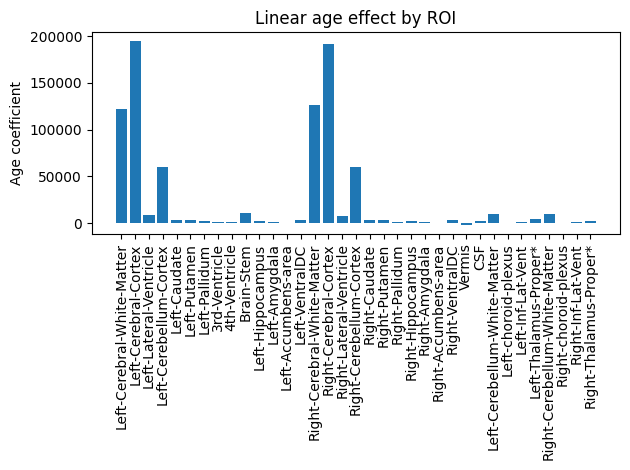

In [10]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# PREPARE DATA
# Define source and output data file paths provided in repo
src = "data/src"
out_dir = "data/outputs"

# Define age column and ROI columns to loop through from HBCD data (exclude age columns and Unknown ROI)
# NOTE! Can use T1w or T2w results here
age_col='img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'
prefix='img_bibsnet_space-T1w_desc-aseg_volumes_'
roi_cols = [col for col in df.columns if col.startswith(prefix) and 'age' not in col and 'Unknown' not in col]

# POLYNOMIAL FIT
# Compute model weights for each ROI using a polynomial fit of age to volume, and store in a new dataframe
roi_weights = []
    
for roi in roi_cols:
    roi_name = roi.replace(prefix, '') # strip prefix for ROIs just for plot
    
    # Flatten into one array (note: ignores repeated participants). Also drop NaNs to avoid issues with polynomial fit
    valid = df[[age_col, roi]].dropna()
    x = valid[age_col].to_numpy().ravel()
    y = valid[roi].to_numpy().ravel()

    # Polynomial fit
    coefs = Polynomial.fit(x, y, deg=2).convert().coef

    roi_weights.append({
        "roi": roi_name,
        "intercept": coefs[0],
        "age_linear": coefs[1],
        "age_quadratic": coefs[2]
    })

# View results as bar plot for linear weights
weights_df = pd.DataFrame(roi_weights)
weights_df.head

# Note! You can replace age_linear here with age_quadratic depending on which model weights are of interest
plt.bar(weights_df['roi'], weights_df['age_linear'])
plt.xticks(rotation=90)
plt.ylabel("Age coefficient") 
plt.title("Linear age effect by ROI") # or 'Quadratic age effect by ROI'
plt.tight_layout()
plt.show()

# REPLACE ROI LABELS IN PROVIDED TEMPLATE BRAIN SEGMENTATION FILE WITH MODEL WEIGHT VALUES
# Read in FreeSurfer lookup table to get FreeSurfer label IDs for each ROI (note: this file only includes the ROIs defined for HBCD data) and merge with weights DF on the roi column to integrate model weights
lut_df = pd.read_csv(f"{src}/FreeSurfer-LUT-short.csv")
roi_df = pd.merge(lut_df, weights_df, on="roi", how="inner")
roi_df.head

# Convert FreeSurfer ROI labels to model weight values (output as file roi_weights_volume.nii.gz)
template_aseg = f'{src}/sub-380056/ses-7mo/anat/sub-380056_ses-7mo_space-INFANTMNIacpc_desc-aseg_dseg.nii.gz'
out_vol = f'{out_dir}/roi_weights_volume.nii.gz' # Adjust this filename as wanted (e.g. to specify linear vs quadratic model weights mapped)

# Load aseg
aseg_img = nib.load(template_aseg)
aseg_data = aseg_img.get_fdata().astype(int)

# Create output array (float for weights)
weights_data = np.zeros_like(aseg_data, dtype=float)

# Map labels > weights and apply mapping
# Note! You can replace age_linear here with age_quadratic depending on which model weights are of interest
label_to_weight = dict(zip(roi_df["label"], roi_df["age_linear"]))
for label, weight in label_to_weight.items():
    weights_data[aseg_data == label] = weight

# Save new NIfTI
out_img = nib.Nifti1Image(weights_data, affine=aseg_img.affine, header=aseg_img.header)
nib.save(out_img, out_vol)

## Statistical Comparison
UMA compared to HBCD

In [ ]:
# If needed
# !pip3 install seaborn

In [11]:
import seaborn as sns
print(sns.__version__)

0.13.2


## Violin plots for example structure
Structure = img_bibsnet_space-T1w_desc-aseg_volumes_**Left-Cerebral-Cortex**

UMA age range: [0.465, 0.643] years


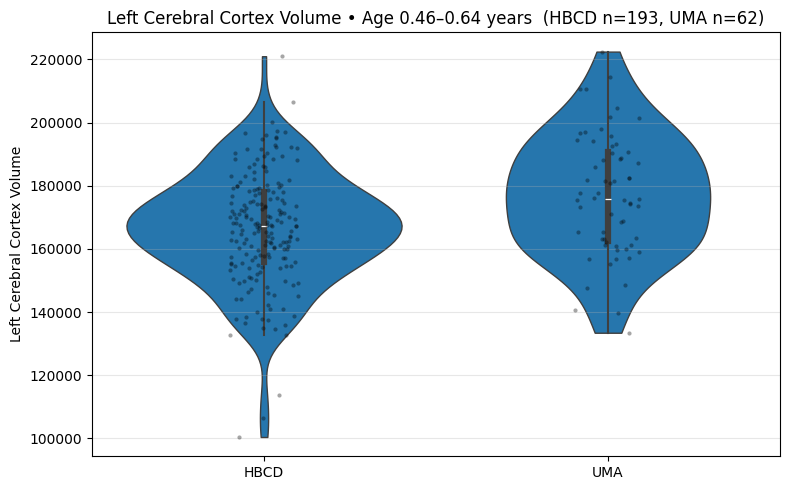

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Column names (as in your data) ----
hbcd_age_col = 'img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'
hbcd_vol_col = 'img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'

uma_age_col = 'Baby Age at Scan (Years)'
uma_vol_col = 'Left-Cerebral-Cortex'

# ---- 1) Determine age range from UMA ----
age_min = df_uma[uma_age_col].min()
age_max = df_uma[uma_age_col].max()

print(f"UMA age range: [{age_min:.3f}, {age_max:.3f}] years")

# ---- 2) Filter HBCD to this age range ----
hbcd_subset = (
    df.loc[df[hbcd_age_col].between(age_min, age_max), [hbcd_age_col, hbcd_vol_col]]
      .dropna()
      .rename(columns={hbcd_age_col: 'Age', hbcd_vol_col: 'Volume'})
      .assign(Source='HBCD')
)

# For fairness, also drop NAs from UMA and (optionally) keep UMA data as-is.
uma_subset = (
    df_uma.loc[:, [uma_age_col, uma_vol_col]]
      .dropna()
      .rename(columns={uma_age_col: 'Age', uma_vol_col: 'Volume'})
      .assign(Source='UMA')
)

# ---- 3) Combine and plot side-by-side violins ----
both = pd.concat([hbcd_subset, uma_subset], ignore_index=True)

# Counts for labeling
n_hbcd = (both['Source'] == 'HBCD').sum()
n_uma = (both['Source'] == 'UMA').sum()

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=both, x='Source', y='Volume',
    inner='box', cut=0, linewidth=1, saturation=0.9
)

# Optional: overlay jittered points to see individuals
sns.stripplot(
    data=both, x='Source', y='Volume',
    color='k', size=3, alpha=0.35
)

plt.title(f'Left Cerebral Cortex Volume • Age {age_min:.2f}–{age_max:.2f} years  (HBCD n={n_hbcd}, UMA n={n_uma})')
plt.xlabel('')
plt.ylabel('Left Cerebral Cortex Volume')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Test the distributions for differences

In [ ]:
# If needed
# !pip3 install statsmodels

In [13]:
import numpy as np
import pandas as pd
from scipy import stats

# Optional imports for equivalence test and regression (install statsmodels if needed)
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --------------------------
# Column names (as in your data)
hbcd_age_col = 'img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'
hbcd_vol_col = 'img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'

uma_age_col = 'Baby Age at Scan (Years)'
uma_vol_col = 'Left-Cerebral-Cortex'
# --------------------------

# 1) Age window from UMA
age_min = df_uma[uma_age_col].min()
age_max = df_uma[uma_age_col].max()
print(f"UMA age range: [{age_min:.3f}, {age_max:.3f}] years")

# 2) Filter to the comparable window and clean
hbcd_sub = (
    df.loc[df[hbcd_age_col].between(age_min, age_max), [hbcd_age_col, hbcd_vol_col]]
      .dropna()
      .rename(columns={hbcd_age_col:'Age', hbcd_vol_col:'Volume'})
)
uma_sub = (
    df_uma.loc[:, [uma_age_col, uma_vol_col]]
      .dropna()
      .rename(columns={uma_age_col:'Age', uma_vol_col:'Volume'})
)

x = hbcd_sub['Volume'].to_numpy()
y = uma_sub['Volume'].to_numpy()

n_hbcd, n_uma = len(x), len(y)
print(f"HBCD n={n_hbcd}, UMA n={n_uma}")

# Helper: Hedges' g (unbiased Cohen's d)
def hedges_g(x, y):
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sp2 = ((nx-1)*vx + (ny-1)*vy) / (nx + ny - 2) if (nx+ny-2) > 0 else np.nan
    d = (np.mean(x) - np.mean(y)) / np.sqrt(sp2) if sp2 > 0 else np.nan
    J = 1 - (3 / (4*(nx + ny) - 9)) if (nx + ny) > 2 else 1.0
    return J * d

# 3) Classic two-sample tests
welch_t, welch_p = stats.ttest_ind(x, y, equal_var=False, alternative='two-sided')
mw_u, mw_p = stats.mannwhitneyu(x, y, alternative='two-sided')
ks_stat, ks_p = stats.ks_2samp(x, y, alternative='two-sided', mode='auto')
lev_stat, lev_p = stats.levene(x, y, center='median')

g = hedges_g(x, y)

print("\n--- Unadjusted two-sample tests ---")
print(f"Welch t-test: t={welch_t:.3f}, p={welch_p:.4g}")
print(f"Mann–Whitney U: U={mw_u:.1f}, p={mw_p:.4g}")
print(f"KS test (distributions): D={ks_stat:.3f}, p={ks_p:.4g}")
print(f"Levene’s test (variances): stat={lev_stat:.3f}, p={lev_p:.4g}")
print(f"Effect size: Hedges' g={g:.3f}")

# 4) Equivalence test (TOST) for the mean difference
# Define a *practical* equivalence margin Δ.
# Common choices:
#   - absolute margin: e.g., Δ_abs = 0.05 * np.mean(x)  # 5% of HBCD mean
#   - SD-based margin: Δ_abs = 0.2 * np.std(x, ddof=1)  # 0.2 SD (small effect)
delta = 0.2 * np.std(x, ddof=1)  # <-- adjust to your tolerance!

mean_diff = np.mean(y) - np.mean(x)

# Manual TOST with Welch SE
vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
se = np.sqrt(vx/n_hbcd + vy/n_uma)
# Welch-Satterthwaite df
df_welch = (vx/n_hbcd + vy/n_uma)**2 / ((vx**2)/((n_hbcd**2)*(n_hbcd-1)) + (vy**2)/((n_uma**2)*(n_uma-1)))

t_lower = (mean_diff - (-delta)) / se   # test H1: diff > -delta
t_upper = (mean_diff - ( delta)) / se   # test H1: diff <  delta
p_lower = 1 - stats.t.cdf(t_lower, df=df_welch)   # one-sided
p_upper = stats.t.cdf(t_upper, df=df_welch)       # one-sided
tost_p = max(p_lower, p_upper)  # TOST rejects (i.e., equivalence) if BOTH one-sided tests are significant

print("\n--- Equivalence test (TOST; mean difference) ---")
print(f"Margin Δ = {delta:.4g} (absolute units)")
print(f"Mean(UMA) - Mean(HBCD) = {mean_diff:.4g}")
print(f"TOST one-sided p-values: p_lower={p_lower:.4g}, p_upper={p_upper:.4g}")
print(f"TOST conclusion: {'EQUIVALENT (within Δ)' if (p_lower < 0.05 and p_upper < 0.05) else 'Not equivalent at α=0.05'}")

# 5) Age-adjusted regression (ANCOVA style): Volume ~ Source + Age + Age^2
both = (
    pd.concat([
        hbcd_sub.assign(Source='HBCD'),
        uma_sub.assign(Source='UMA')
    ], ignore_index=True)
)

# Optional: center age to improve stability
both['Age_c'] = both['Age'] - both['Age'].mean()
both['Age2_c'] = both['Age_c']**2

model = ols('Volume ~ C(Source) + Age_c + Age2_c', data=both).fit(cov_type='HC3')  # robust SEs
print("\n--- Age-adjusted OLS (robust SEs) ---")
print(model.summary().as_text())

src_coef = model.params.get('C(Source)[T.UMA]', np.nan)
src_pval = model.pvalues.get('C(Source)[T.UMA]', np.nan)
print(f"\nSource(UMA vs HBCD): coef={src_coef:.4g}, p={src_pval:.4g}")

UMA age range: [0.465, 0.643] years
HBCD n=193, UMA n=62

--- Unadjusted two-sample tests ---
Welch t-test: t=-3.905, p=0.0001745
Mann–Whitney U: U=4128.0, p=0.0002421
KS test (distributions): D=0.276, p=0.001177
Levene’s test (variances): stat=1.422, p=0.2342
Effect size: Hedges' g=-0.592

--- Equivalence test (TOST; mean difference) ---
Margin Δ = 3541 (absolute units)
Mean(UMA) - Mean(HBCD) = 1.072e+04
TOST one-sided p-values: p_lower=5.687e-07, p_upper=0.9948
TOST conclusion: Not equivalent at α=0.05

--- Age-adjusted OLS (robust SEs) ---
                            OLS Regression Results                            
Dep. Variable:                 Volume   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     17.37
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.80e-10
Time:                        03:01:58   Log-Likelihood: 